<a href="https://colab.research.google.com/github/w2dw3d232wa/HumanProteinImageClassification/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch    0 | Loss: 1432.0695
Epoch  500 | Loss: 151.7755
Epoch 1000 | Loss: 151.7755
Epoch 1500 | Loss: 151.7755
Epoch 2000 | Loss: 151.7755
Epoch 2500 | Loss: 151.7755

Model Accuracy: 78.00%


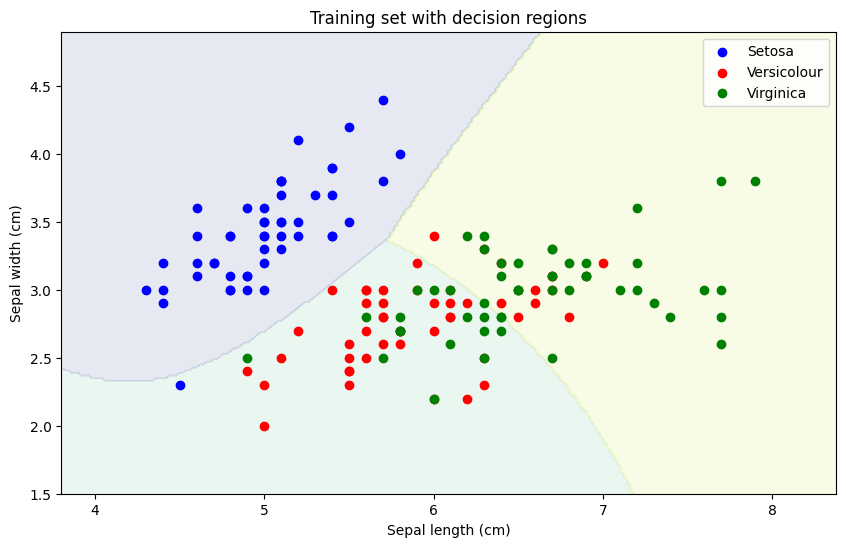

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn import datasets, model_selection
from matplotlib.colors import ListedColormap

# ==========================================
# STEP 1: Load and preprocess the data
# ==========================================
# 載入 Iris 資料集
iris = datasets.load_iris()
# 根據要求，只取 sepal length 和 sepal width 兩個特徵
X = iris.data[:, :2].astype(np.float32)
y = iris.target.astype(np.int32)

num_classes = len(np.unique(y))
num_features = X.shape[1]

# ==========================================
# STEP 2: Construct the custom training loop
# ==========================================
# 為了使用 TensorFlow 訓練，我們將平均值(means)與標準差(scales)設為可訓練變數
# 初始值給予隨機常態分佈
means = tf.Variable(tf.random.normal([num_classes, num_features], mean=5.0, stddev=1.0))

# 標準差必須大於 0，因此我們使用一個 raw 變數，後續用 softplus 轉換
scales_raw = tf.Variable(tf.random.normal([num_classes, num_features], mean=0.0, stddev=1.0))

# 定義優化器
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

# 計算損失的函數：負對數似然 (Negative Log-Likelihood)
@tf.function
def compute_loss():
    # 確保標準差為正數
    scales = tf.math.softplus(scales_raw) + 1e-5
    loss = 0.0
    for c in range(num_classes):
        # 取出屬於該類別的特徵資料
        X_c = X[y == c]
        # 建立高斯分佈模型
        dist_c = tfd.Normal(loc=means[c], scale=scales[c])
        # 計算對數機率並加總 (加上負號變成 Loss)
        loss -= tf.reduce_sum(dist_c.log_prob(X_c))
    return loss

# ==========================================
# STEP 3: Train the model
# ==========================================
epochs = 3000
loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = compute_loss()

    # 計算梯度並更新變數
    grads = tape.gradient(loss, [means, scales_raw])
    optimizer.apply_gradients(zip(grads, [means, scales_raw]))

    loss_history.append(loss.numpy())
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.numpy():.4f}")

# ==========================================
# STEP 4: Measure model’s accuracy
# ==========================================
# 使用訓練好的參數建立最終的預測模型
final_scales = tf.math.softplus(scales_raw) + 1e-5
final_dist = tfd.Normal(loc=means, scale=final_scales)

# 計算預測機率：將每個樣本帶入三個類別的分佈中計算 log_prob
# 加上 tf.newaxis 讓維度對齊，計算後在特徵維度(axis=2)加總
log_probs = tf.reduce_sum(final_dist.log_prob(X[:, tf.newaxis, :]), axis=2)

# 取機率最大的類別作為預測結果
y_pred = tf.argmax(log_probs, axis=1).numpy()
acc = accuracy_score(y, y_pred)
print(f"\nModel Accuracy: {acc * 100:.2f}%")

# ==========================================
# STEP 5: Plot the decision regions
# ==========================================
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_log_probs = tf.reduce_sum(final_dist.log_prob(grid_points[:, tf.newaxis, :]), axis=2)
Z = tf.argmax(grid_log_probs, axis=1).numpy()
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
# 建立自訂的 Colormap 物件
custom_cmap = ListedColormap(['#B0B8D6', '#BCE2D0', '#EBF4AB'])

# 使用 custom_cmap 畫出決策邊界
plt.contourf(xx, yy, Z, alpha=0.3, cmap=custom_cmap)
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Setosa')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Versicolour')
plt.scatter(X[y==2, 0], X[y==2, 1], color='green', label='Virginica')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('Training set with decision regions')
plt.legend()
plt.show()

Step 6 Dicussion
1. A note regarding Gaussian distributions (關於高斯分佈的說明)
當我們處理連續數值型的特徵（如本實驗中的花萼長度與寬度）時，我們無法像類別型資料那樣直接計算頻率。因此，我們必須假設這些特徵在每個分類下都服從高斯（常態）分佈 。這意味著我們認為同一種鳶尾花的特徵值會集中在一個平均值附近，並呈現鐘形曲線遞減。透過 TensorFlow，我們實際上是在利用梯度下降尋找能完美套用在這些數據上的常態分佈參數 ($\mu$ 和 $\sigma$)。

2. Pros and cons of naive Bayes classifier


*   優點:
(1)容易實作與計算快速：相較於複雜的類神經網路，它的數學結構簡單
(2)漸進式學習 (Incremental)：每增加一筆新的訓練資料，都可以直接用來更新機率分佈，不需要從頭訓練整個模型
(3)效能穩定：儘管假設簡單，但在許多實際應用上（如文本分類），它的表現足以媲美決策樹或部分神經網路模型
*   缺點:
(1)現實世界中條件都會有相關聯，導致準確率會流失
(2)如果訓練樣本沒有某樣本的特徵值，會需要用到拉普拉斯平滑法來優化此分類器